In [43]:
# =============================================================================
# SEASONALITY FEATURES — Random Forest, LSTM, SARIMAX
# Drop these cells into your notebook after the pipeline() definition.
# New features added to monthly_df: month_sin, month_cos, year_scaled
# =============================================================================

import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [44]:
train_size = 0.75

In [45]:


# ── helpers ──────────────────────────────────────────────────────────────────


def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def add_seasonality_features(monthly_df: pd.DataFrame) -> pd.DataFrame:
    """
    Append cyclical month encoding + scaled year to a monthly DatetimeIndex df.

    Why sine/cosine for month?
      A raw month integer (1-12) implies that December (12) is far from
      January (1), but they are actually adjacent.  Encoding on the unit
      circle preserves that continuity:
        month_sin = sin(2π * month / 12)
        month_cos = cos(2π * month / 12)
      Together they uniquely identify every month and respect the cycle.

    Why scaled year?
      The year captures long-run trend (prices generally rise over time).
      We centre and scale it so it sits on a similar numerical range to the
      other features, which helps gradient-based optimisers (LSTM) converge.
    """
    df = monthly_df.copy()
    month = df.index.month
    year = df.index.year

    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)
    df["year_scaled"] = (year - year.mean()) / year.std()

    return df

In [46]:
def plot_price_distribution(df):
    plt.figure(figsize=(10, 6))
    sns.histplot(df['price'], kde=True)
    plt.title('Distribution of Property Prices')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

def plot_price_trend(monthly):
    plt.figure(figsize=(12, 6))
    plt.plot(monthly.index, monthly['price'], color='lightgray', label='Original', linewidth=1.5)
    plt.plot(monthly.index, monthly['price_rolling'], color='blue', label='Smoothed', linewidth=2)
    plt.title('Mean Price Over Time')
    plt.xlabel('Date')
    plt.ylabel('Mean Price')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_monthly_trend(monthly_df):
    monthly_df[['price', 'avg_bedrooms', 'house_ratio', 'sales_count']].plot(
        subplots=True, figsize=(10, 8), title='Monthly Trends')
    plt.tight_layout()
    plt.show()

In [47]:
# KNNImputer

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

def imputer_pipeline(df):

    df2 = df.copy()

    df2['bedrooms'] = df2['bedrooms'].replace(0,np.nan)

    le = LabelEncoder()
    df2['type_encoded'] = le.fit_transform(df2['type'])

    features = ['price', 'type_encoded', 'bedrooms']
    X = df2[features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    imputer = KNNImputer(n_neighbors=5, weights='distance')
    X_imputed = imputer.fit_transform(X_scaled)
    X_unscaled = scaler.inverse_transform(X_imputed)
    df2['bedrooms'] = X_unscaled[:,2]

    df2['bedrooms'] = df2['bedrooms'].round().astype(int)
    df2['bedrooms'] = df2['bedrooms'].clip(lower=1, upper=5)
    df2['bedrooms'].value_counts()

    return df2

from sklearn.preprocessing import PowerTransformer

def pipeline(df, type_of_outlier, plotting=True):

    # we can try different types of handling right-skewed outliers: simply removing them, using log transformation, using power transformation.
    #the first option is to simply remove the outliers from the dataset, which can be done by filtering out the rows that contain outlier values based on a defined threshold (e.g., using the IQR method or Z-score method). This approach can help improve the performance of machine learning models by reducing the influence of extreme values, but it may also lead to loss of valuable information if not done carefully.
    #the second option is to apply a log transformation to the price variable, which can help reduce the impact of outliers and make the distribution more normal. This can be done by creating a new column in the dataframe that contains the log-transformed values of the price variable. This approach can be effective in improving the performance of certain machine learning algorithms that assume normality in the data, such as linear regression
    #the third option is to apply a power transformation to the price variable, which can also help reduce the impact of outliers

    if type_of_outlier == 'none':
        df_cleaned = df.copy()

    elif type_of_outlier == 'remove':
        Q1 = df['price'].quantile(0.25)
        Q3 = df['price'].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_cleaned = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
        
    elif type_of_outlier == 'log_transform':
        df_cleaned = df.copy()
        df_cleaned['price'] = np.log(df_cleaned['price'])
    
    elif type_of_outlier == 'power_transform':
        df_cleaned = df.copy()
        pt = PowerTransformer(method='box-cox') # since price is positive, we can use box-cox transformation.  
        df_cleaned['price'] = pt.fit_transform(df_cleaned[['price']])

    #plot the distribution of the price variable after handling outliers
    if plotting:
        plot_price_distribution(df_cleaned)

    monthly = df_cleaned.resample('ME', on='date').agg({'price':'mean'})
    monthly['price_rolling'] = monthly['price'].rolling(window=3, center=True).mean()

    #plot the original and smoothed mean price over time
    if plotting:
        plot_price_trend(monthly)
    
    df_cleaned['date'] = pd.to_datetime(df_cleaned['date'])
    df_cleaned['month'] = df_cleaned['date'].dt.to_period('M')

    monthly_df = (df_cleaned.groupby('month').agg(
          price=('price', 'mean'),
          house_ratio=('type', lambda x: (x == 'house').mean()),
          avg_bedrooms=('bedrooms', 'mean'),
          sales_count=('price', 'count')
     )
     .reset_index()
    )

    monthly_df['month'] = monthly_df['month'].dt.to_timestamp() # Convert Period to Timestamp for plotting (e.g. 2020-01-01 for January 2020)
    monthly_df.set_index('month', inplace=True)

    # if plotting:
    #     monthly_df.head()

    if plotting:
        plot_monthly_trend(monthly_df)

    return df_cleaned, monthly, monthly_df

In [48]:
data = pd.read_csv('raw_sales.csv')
data.head()

df = data.copy()
df = df.rename(columns={'datesold': 'date', 'propertyType': 'type'})
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,postcode,price,type,bedrooms
0,2007-02-07,2607,525000,house,4
1,2007-02-27,2906,290000,house,3
2,2007-03-07,2905,328000,house,3
3,2007-03-09,2905,380000,house,4
4,2007-03-21,2906,310000,house,3


[RF] RMSE (with seasonality, none): $55,588.42


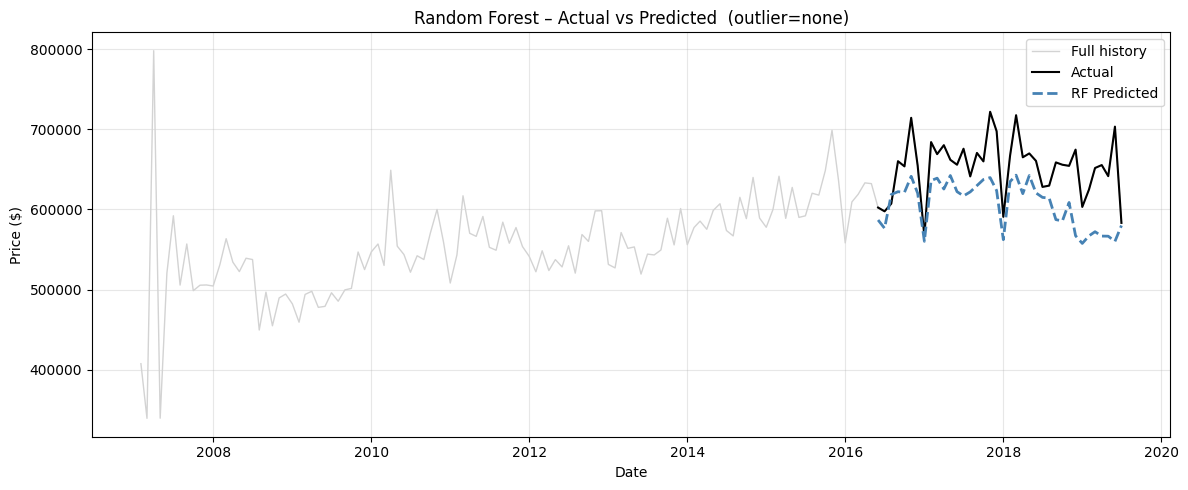

Feature importances:
 sales_count     0.4096
year_scaled     0.2983
avg_bedrooms    0.1878
house_ratio     0.0670
month_cos       0.0212
month_sin       0.0160
dtype: float64


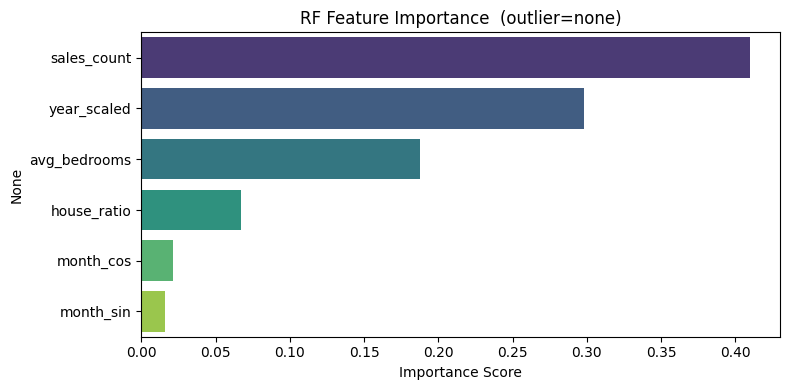

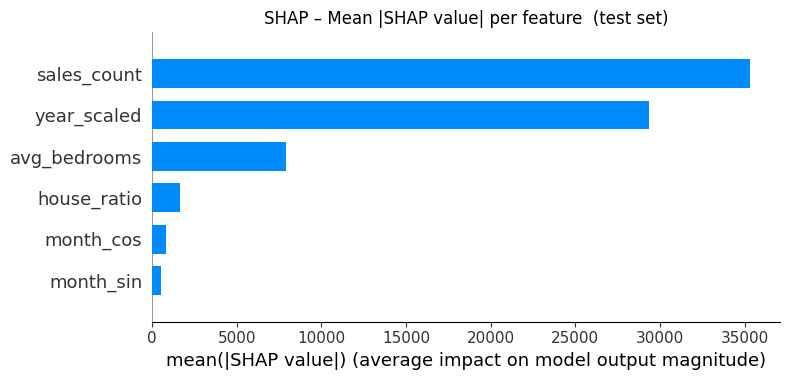

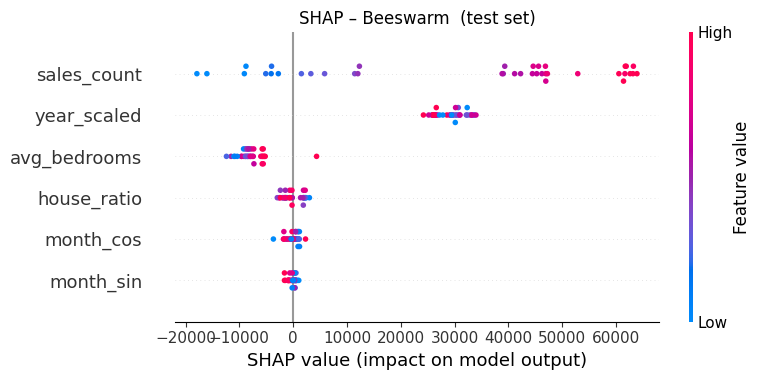

[RF] RMSE (with seasonality, remove): $42,772.02


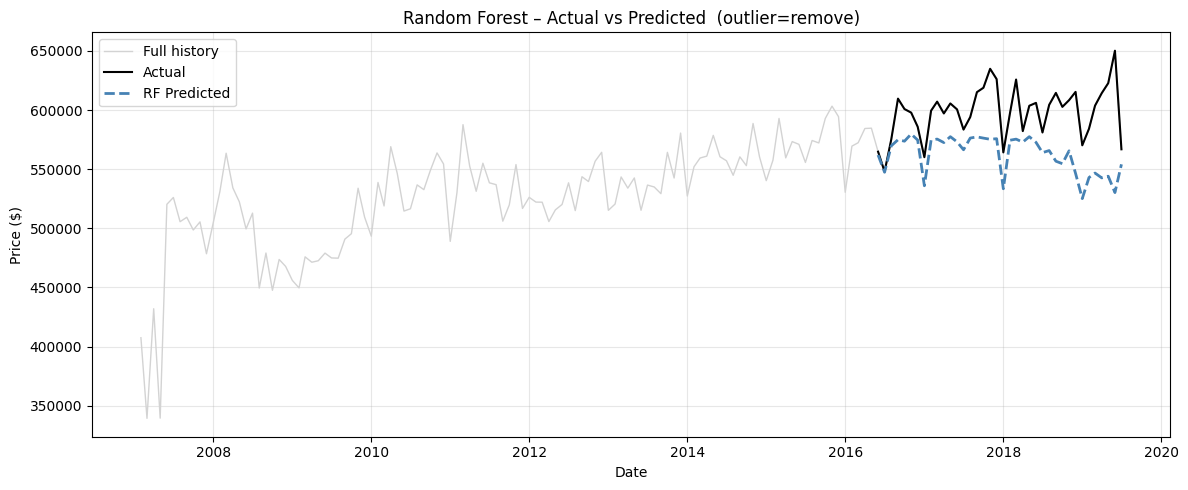

Feature importances:
 sales_count     0.4889
year_scaled     0.3362
avg_bedrooms    0.0805
house_ratio     0.0506
month_sin       0.0247
month_cos       0.0192
dtype: float64


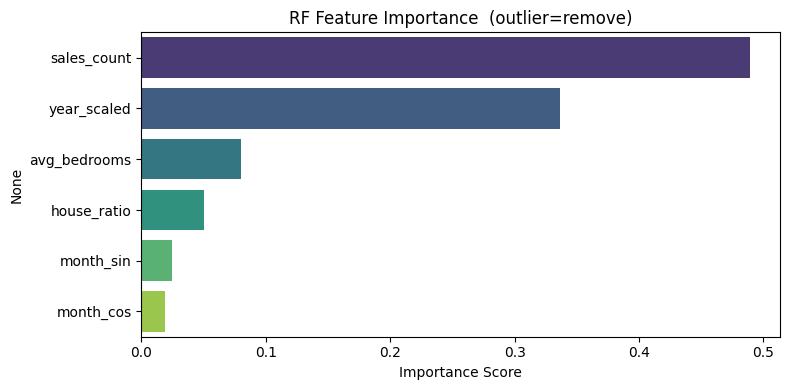

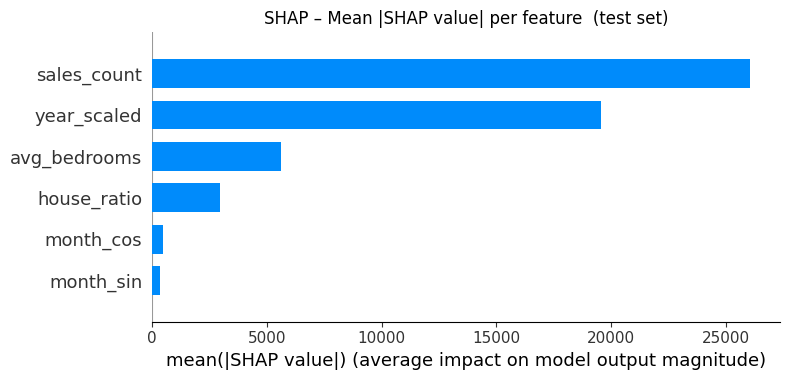

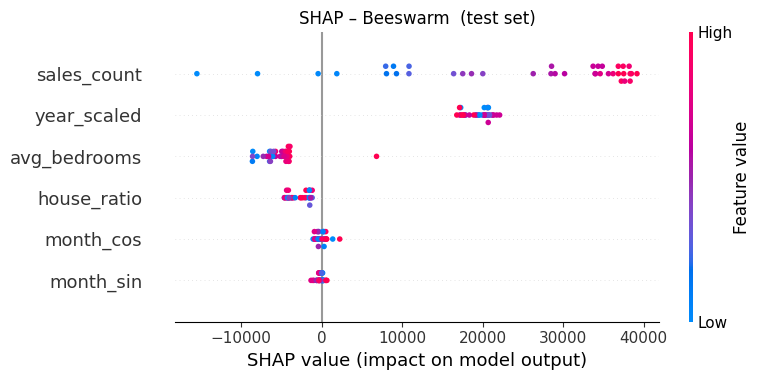

[RF] RMSE (with seasonality, log_transform): $46,787.53


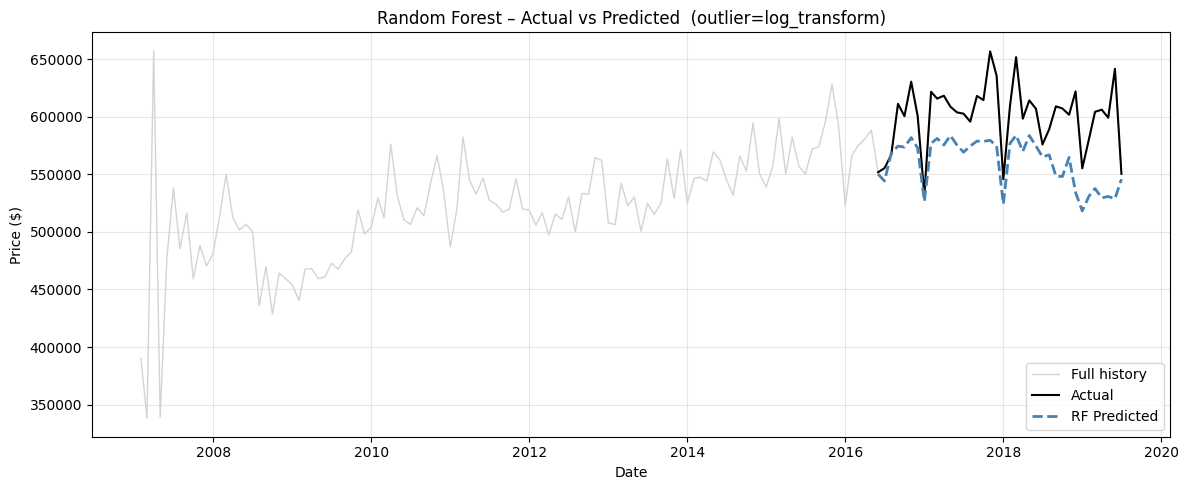

Feature importances:
 sales_count     0.4058
year_scaled     0.3465
avg_bedrooms    0.1482
house_ratio     0.0504
month_sin       0.0264
month_cos       0.0228
dtype: float64


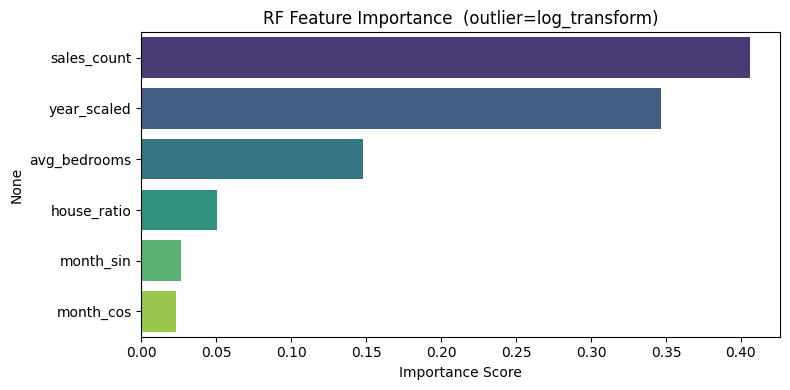

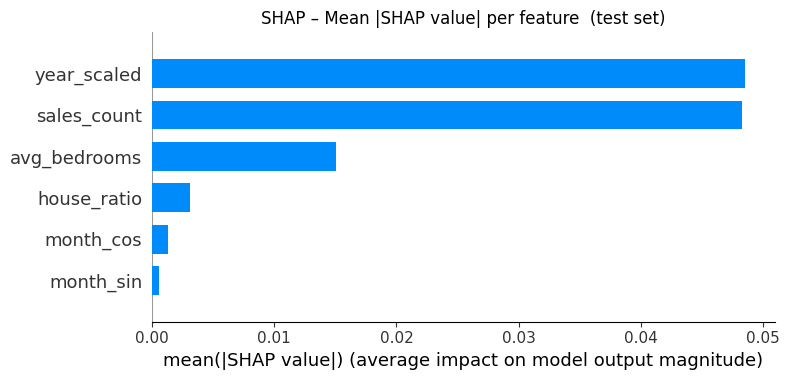

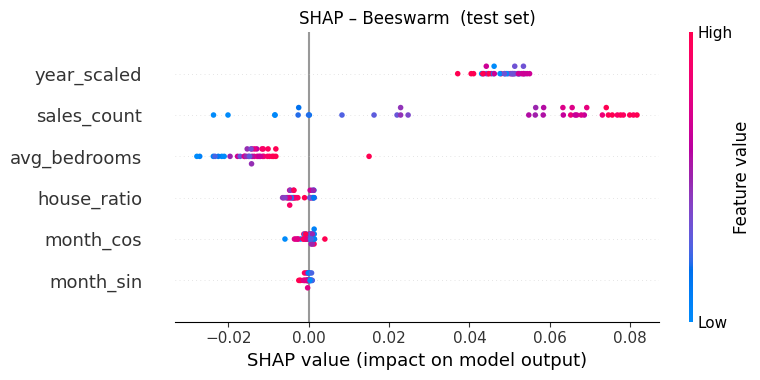

In [49]:
# =============================================================================
# 1.  RANDOM FOREST  +  SHAP
# =============================================================================


def add_seasonality_features(monthly_df_cleaned):
    """
    Add seasonal features (month_sin, month_cos, year_scaled) to the
    aggregated monthly dataframe.

    This implementation avoids calling `.mean()` on a pandas Index,
    which was raising: AttributeError: 'Index' object has no attribute 'mean'.
    """
    df = monthly_df_cleaned.copy()

    # Ensure the index is a DatetimeIndex
    if not np.issubdtype(df.index.dtype, np.datetime64):
        df.index = pd.to_datetime(df.index)

    # Month-based cyclic features
    month_numbers = df.index.month
    df["month_sin"] = np.sin(2 * np.pi * month_numbers / 12)
    df["month_cos"] = np.cos(2 * np.pi * month_numbers / 12)

    # Year, scaled to zero mean / unit std using numpy arrays
    years = df.index.year.astype("int64")
    years_arr = years.to_numpy()
    df["year_scaled"] = (years_arr - years_arr.mean()) / years_arr.std()
    #this extra feature provides the model with information about the long-term trend in prices, which can be important for forecasting. By centering and scaling the year, we ensure that it is on a similar numerical scale to the other features, which can help certain models (like LSTM) converge more effectively during training.
    # when we are trying to predict the mean price over time, it is important to capture the long-term trend.
    #for example, when we try to predict future prices, we need to know that prices have generally been rising over time, so the year feature can help the model learn that upward trend. By scaling it, we make sure it doesn't dominate the learning process due to its larger numerical values compared to other features.

    return df


def run_random_forest_with_seasonality(
    monthly_df_cleaned, train_size, type_of_outlier="remove"
):
    """
    Trains a Random Forest with the three original features PLUS
    month_sin, month_cos, year_scaled.  Produces:
      • Actual vs Predicted plot
      • Feature importance bar chart
      • SHAP summary plot
    Returns (model, rmse_dollars, feature_names)
    """
    df = add_seasonality_features(monthly_df_cleaned)

    FEATURES = [
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "month_sin",
        "month_cos",
        "year_scaled",
    ]

    split_idx = int(len(df) * train_size)
    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:]

    X_train, y_train = train[FEATURES], train["price"]
    X_test, y_test = test[FEATURES], test["price"]

    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    # ── inverse-transform to dollars ─────────────────────────────────────────
    if type_of_outlier == "log_transform":
        actual_dollar = np.exp(y_test.values)
        preds_dollar = np.exp(predictions)
        history_dollar = np.exp(df["price"].values)
    else:
        actual_dollar = y_test.values
        preds_dollar = predictions
        history_dollar = df["price"].values

    rmse = calculate_rmse(actual_dollar, preds_dollar)
    print(f"[RF] RMSE (with seasonality, {type_of_outlier}): ${rmse:,.2f}")

    # ── plot: actual vs predicted ─────────────────────────────────────────────
    plt.figure(figsize=(12, 5))
    plt.plot(
        df.index, history_dollar, color="lightgray", label="Full history", linewidth=1
    )
    plt.plot(test.index, actual_dollar, color="black", label="Actual", linewidth=1.5)
    plt.plot(
        test.index,
        preds_dollar,
        color="steelblue",
        label="RF Predicted",
        linewidth=2,
        linestyle="--",
    )
    plt.title(f"Random Forest – Actual vs Predicted  (outlier={type_of_outlier})")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"rf_seasonality_forecast_{type_of_outlier}.png", dpi=150)
    plt.show()

    # ── feature importance ────────────────────────────────────────────────────
    importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values(
        ascending=False
    )
    print("Feature importances:\n", importance.round(4))

    plt.figure(figsize=(8, 4))
    sns.barplot(x=importance.values, y=importance.index, palette="viridis")
    plt.title(f"RF Feature Importance  (outlier={type_of_outlier})")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig(f"rf_seasonality_importance_{type_of_outlier}.png", dpi=150)
    plt.show()

    # ── SHAP ──────────────────────────────────────────────────────────────────
    # TreeExplainer is exact and fast for tree-based models.
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)  # shape (n_test, n_features)

    plt.figure()
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title("SHAP – Mean |SHAP value| per feature  (test set)")
    plt.tight_layout()
    plt.savefig(f"rf_shap_bar_{type_of_outlier}.png", dpi=150)
    plt.show()

    plt.figure()
    shap.summary_plot(shap_values, X_test, show=False)  # beeswarm
    plt.title("SHAP – Beeswarm  (test set)")
    plt.tight_layout()
    plt.savefig(f"rf_shap_beeswarm_{type_of_outlier}.png", dpi=150)
    plt.show()

    return model, rmse, FEATURES


# ── run across all outlier strategies ────────────────────────────────────────

# (assumes pipeline() and df are already defined in your notebook)
for type_of_outlier in ['none', 'remove', 'log_transform']:
    _, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier=type_of_outlier, plotting=False)
    run_random_forest_with_seasonality(monthly_df_cleaned, train_size, type_of_outlier)

[LSTM] RMSE (with seasonality, none): $42,088.68


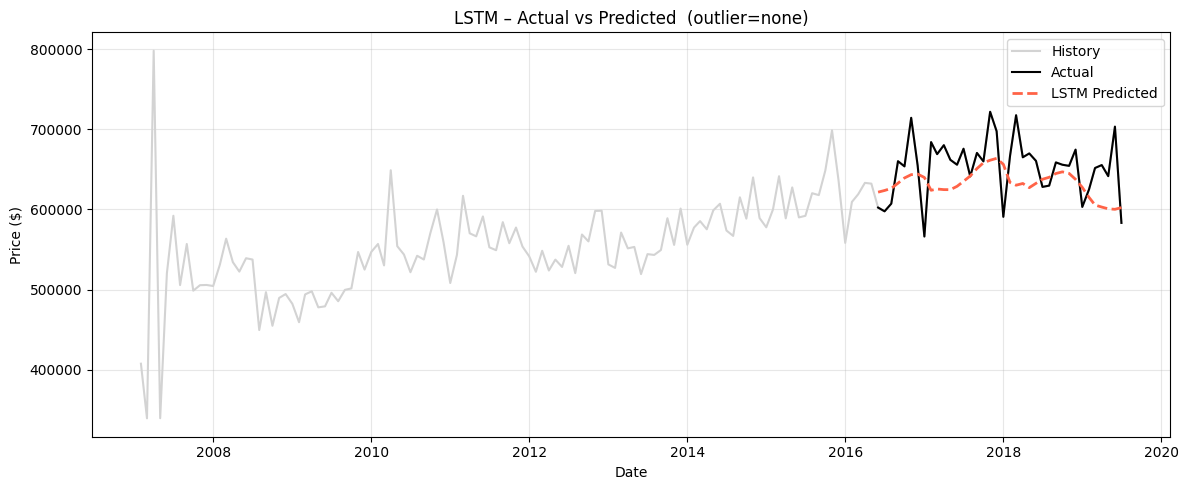

100%|██████████| 38/38 [00:26<00:00,  1.45it/s]


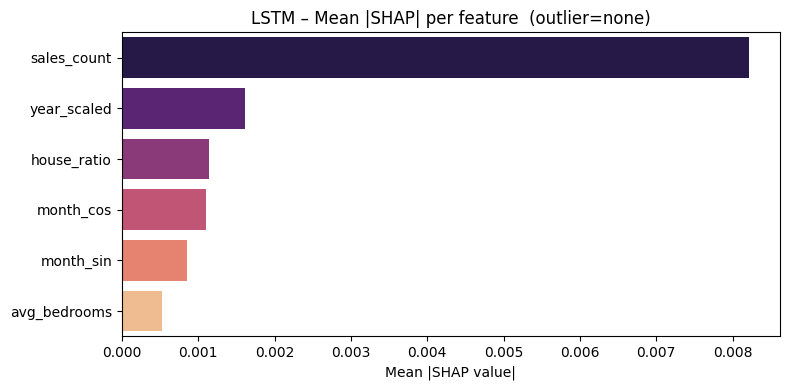

[LSTM] RMSE (with seasonality, remove): $24,006.11


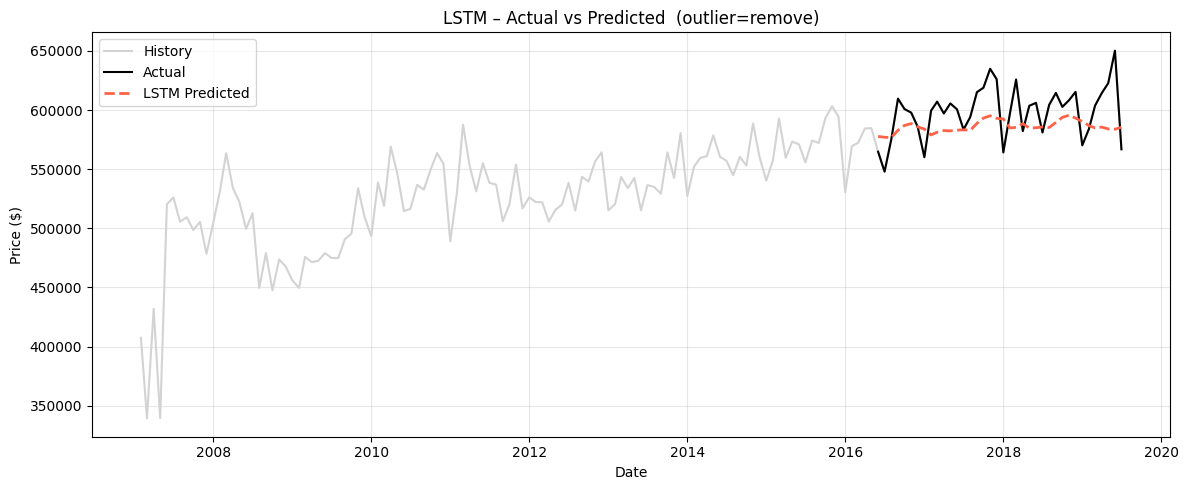

100%|██████████| 38/38 [00:28<00:00,  1.35it/s]


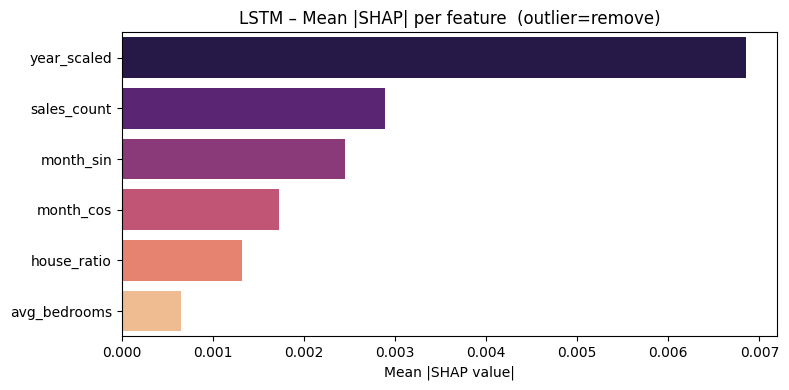

[LSTM] RMSE (with seasonality, log_transform): $32,069.76


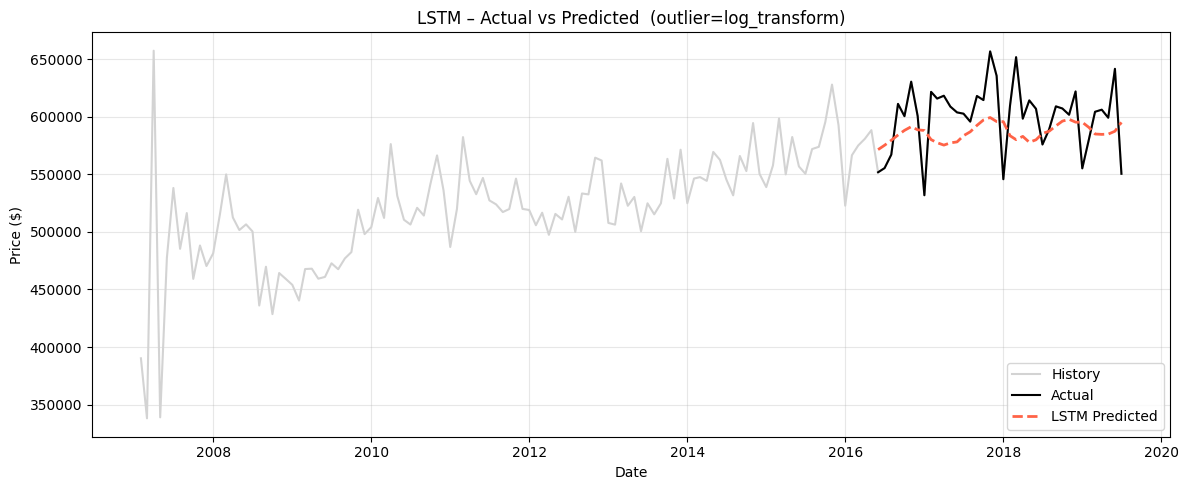

100%|██████████| 38/38 [00:30<00:00,  1.27it/s]


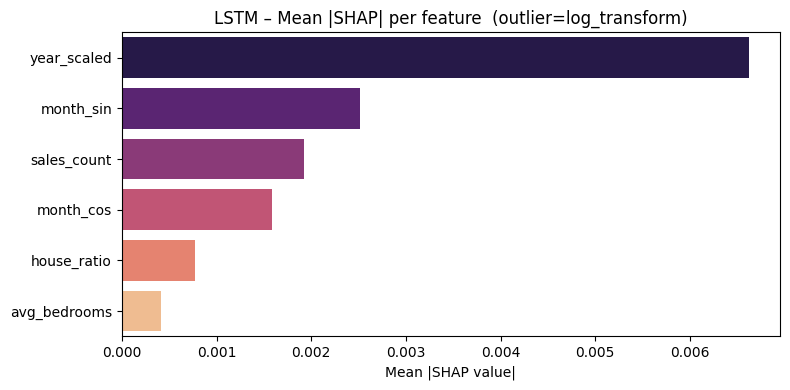

In [54]:
# =============================================================================
# 2.  MULTIVARIATE LSTM  +  SHAP  (GradientExplainer)
# =============================================================================


def create_sequences(X, y, seq_len=12):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i : i + seq_len])
        ys.append(y[i + seq_len])
    return np.array(Xs), np.array(ys)


def run_lstm_with_seasonality(
    monthly_df_cleaned, train_size, type_of_outlier="remove", seq_len=12
):
    """
    Multivariate LSTM using original features + month_sin, month_cos, year_scaled.

    Architecture:
      LSTM(64) → Dense(32, relu) → Dense(1)

    Scaling strategy:
      • Features and target are scaled separately with MinMaxScaler.
      • Scalers are fit ONLY on train to avoid data leakage.
      • Forecasting on the test set is done recursively: after each step the
        predicted price is fed back into the input sequence so the model only
        needs real future values of the exogenous features (bedrooms, ratio,
        counts, seasonality) — which we know in advance for monthly data.

    SHAP:
      LSTM is not tree-based, so we use shap.GradientExplainer which applies
      integrated gradients through the Keras graph.  We explain predictions
      on the test sequences.  Because input is 3-D (samples, timesteps, features)
      we average SHAP values over the seq_len time-steps to get one value per
      feature, making the summary plot interpretable.
    """
    # Build seasonality features directly here to ensure all columns are 1-D
    df = monthly_df_cleaned.copy()

    # Extract month and year from the DateTimeIndex
    df["month_num"] = df.index.month
    df["year"] = df.index.year

    # Cyclical encoding for the month
    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12.0)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12.0)

    # Simple min-max scaling for the year (kept strictly 1-D)
    year_min = df["year"].min()
    year_max = df["year"].max()
    df["year_scaled"] = (df["year"] - year_min) / (year_max - year_min)

    FEATURES = [
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "month_sin",
        "month_cos",
        "year_scaled",
    ]
    TARGET = "price"

    # ── split BEFORE scaling ──────────────────────────────────────────────────
    split_idx = int(len(df) * train_size)
    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:]

    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaler_X.fit(train_df[FEATURES])
    scaler_y.fit(train_df[[TARGET]])

    train_scaled = scaler_X.transform(train_df[FEATURES])
    test_scaled = scaler_X.transform(test_df[FEATURES])
    y_train_sc = scaler_y.transform(train_df[[TARGET]])
    y_test_sc = scaler_y.transform(test_df[[TARGET]])

    X_train_seq, y_train_seq = create_sequences(train_scaled, y_train_sc, seq_len)

    # ── build model ───────────────────────────────────────────────────────────
    model = Sequential(
        [
            LSTM(64, return_sequences=False, input_shape=(seq_len, len(FEATURES))),
            Dense(32, activation="relu"),
            Dense(1),
        ]
    )
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=16, verbose=0)

    # ── recursive forecasting on test set ────────────────────────────────────
    # We know future seasonality & property-mix features exactly, so only the
    # price column is updated recursively; the other features use ground truth.
    current_seq = train_scaled[-seq_len:].copy()  # (seq_len, n_features)
    preds_scaled = []
    price_col_idx = FEATURES.index("avg_bedrooms")  # we'll replace price separately

    # Build a full array of test feature rows (exog known + placeholder price)
    # Price column position in FEATURES is not included — price is the target.
    # The sequence rows contain only the 6 exogenous features; price is separate.
    # Strategy: replace the last column of the sequence with the predicted price
    # scaled by scaler_y, then update all other columns with true test features.

    # Simpler & common approach: treat all 6 as known at test time (valid because
    # seasonality / house_ratio / bedrooms / sales_count are not price itself).
    for i in range(len(test_scaled)):
        inp = current_seq.reshape(1, seq_len, len(FEATURES))
        pred = model.predict(inp, verbose=0)[0, 0]
        preds_scaled.append(pred)
        # Shift window: drop oldest row, append new test row
        new_row = test_scaled[i].copy()
        current_seq = np.vstack([current_seq[1:], new_row])

    preds_scaled = np.array(preds_scaled).reshape(-1, 1)
    preds_dollar = scaler_y.inverse_transform(preds_scaled).flatten()
    actual_dollar = scaler_y.inverse_transform(y_test_sc).flatten()

    if type_of_outlier == "log_transform":
        preds_dollar = np.exp(preds_dollar)
        actual_dollar = np.exp(actual_dollar)

    rmse = calculate_rmse(actual_dollar, preds_dollar)
    print(f"[LSTM] RMSE (with seasonality, {type_of_outlier}): ${rmse:,.2f}")

    # ── plot ──────────────────────────────────────────────────────────────────
    history_dollar = scaler_y.inverse_transform(
        scaler_y.transform(df[[TARGET]])
    ).flatten()
    if type_of_outlier == "log_transform":
        history_dollar = np.exp(history_dollar)

    plt.figure(figsize=(12, 5))
    plt.plot(df.index, history_dollar, color="lightgray", label="History")
    plt.plot(test_df.index, actual_dollar, color="black", label="Actual")
    plt.plot(
        test_df.index,
        preds_dollar,
        color="tomato",
        label="LSTM Predicted",
        linewidth=2,
        linestyle="--",
    )
    plt.title(f"LSTM – Actual vs Predicted  (outlier={type_of_outlier})")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"lstm_seasonality_forecast_{type_of_outlier}.png", dpi=150)
    plt.show()

    # ── SHAP via KernelExplainer (works with 2-D tabular input) ──────────────
    # Build test sequences for explanation (non-recursive, uses true values)
    all_scaled = np.vstack([train_scaled, test_scaled])
    all_y_sc = np.vstack([y_train_sc, y_test_sc])
    X_all_seq, _ = create_sequences(all_scaled, all_y_sc, seq_len)
    X_test_seq = X_all_seq[split_idx - seq_len :]  # align with test period

    # Background dataset (sample of train sequences)
    X_train_seq_all, _ = create_sequences(train_scaled, y_train_sc, seq_len)
    background = X_train_seq_all[
        np.random.choice(
            len(X_train_seq_all), size=min(100, len(X_train_seq_all)), replace=False
        )
    ]

    # Flatten sequences to 2-D for KernelExplainer
    background_2d = background.reshape(background.shape[0], -1)
    X_test_2d = X_test_seq.reshape(X_test_seq.shape[0], -1)

    def predict_fn(x_2d):
        x_3d = x_2d.reshape(-1, seq_len, len(FEATURES))
        return model.predict(x_3d, verbose=0).flatten()

    explainer = shap.KernelExplainer(predict_fn, background_2d)
    shap_values = explainer.shap_values(X_test_2d, nsamples=100)

    # shap_values can be a list (one array per output) or a single array
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # Restore (samples, seq_len, n_features) structure
    shap_values_3d = shap_values.reshape(-1, seq_len, len(FEATURES))

    # Average absolute SHAP over the time-step dimension → (n, n_features)
    shap_2d = np.abs(shap_values_3d).mean(axis=1)
    mean_shap = shap_2d.mean(axis=0)

    plt.figure(figsize=(8, 4))
    sorted_idx = np.argsort(mean_shap)[::-1]
    sns.barplot(
        x=mean_shap[sorted_idx], y=np.array(FEATURES)[sorted_idx], palette="magma"
    )
    plt.title(f"LSTM – Mean |SHAP| per feature  (outlier={type_of_outlier})")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.savefig(f"lstm_shap_{type_of_outlier}.png", dpi=150)
    plt.show()

    return model, rmse, FEATURES

for type_of_outlier in ['none', 'remove', 'log_transform']:
    _, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier=type_of_outlier, plotting=False)
    run_lstm_with_seasonality(monthly_df_cleaned, train_size, type_of_outlier)

Train: 112 months | Test: 38 months
                                        SARIMAX Results                                        
Dep. Variable:                                   price   No. Observations:                  112
Model:             SARIMAX(0, 1, 1)x(1, 0, [1, 2], 12)   Log Likelihood               -1265.583
Date:                                 Fri, 20 Feb 2026   AIC                           2553.166
Time:                                         14:35:55   BIC                           2582.971
Sample:                                     02-01-2007   HQIC                          2565.257
                                          - 05-01-2016                                         
Covariance Type:                                robust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
avg_bedrooms  1.484e+05   2.99e+04

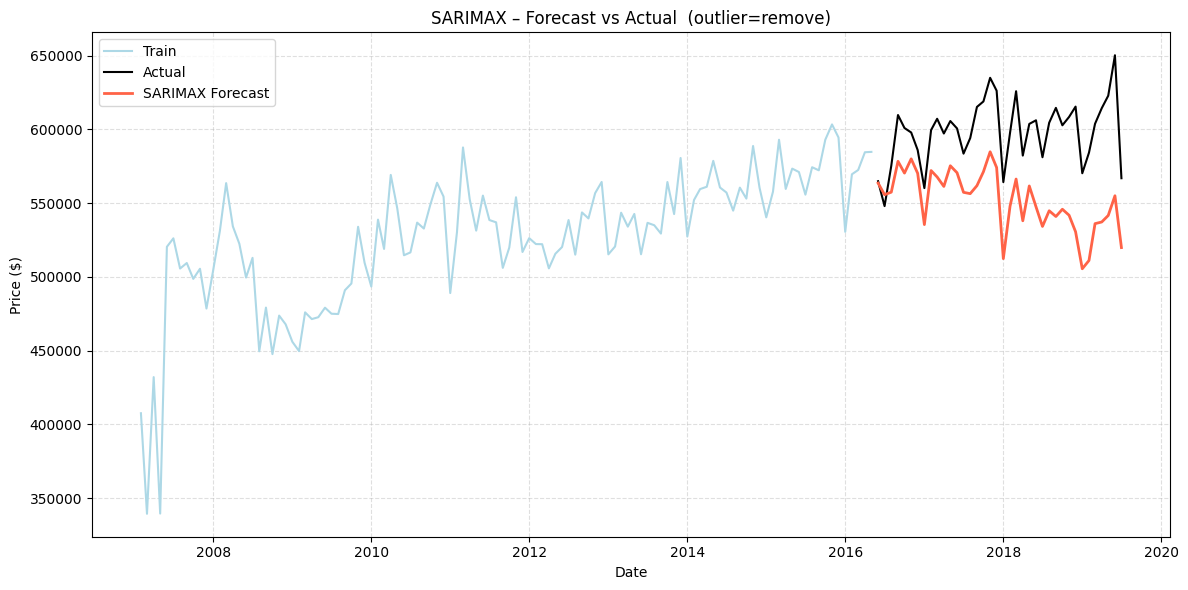

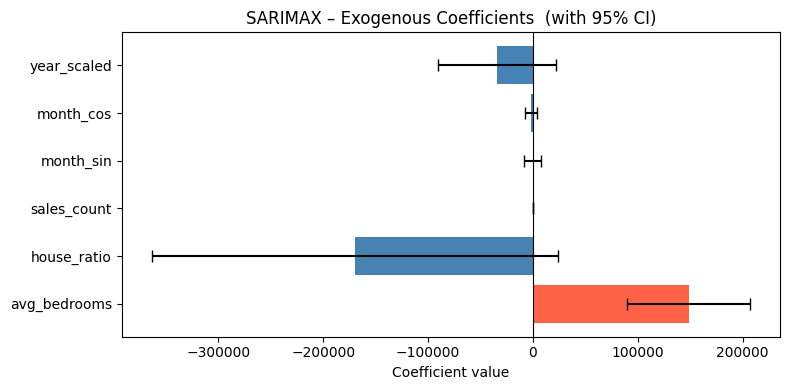

In [60]:

# =============================================================================
# 3.  SARIMAX  with seasonality exogenous features
# =============================================================================
#
# NOTE ON SARIMAX + SEASONALITY FEATURES
# ───────────────────────────────────────
# SARIMAX already handles seasonal auto-correlation through its seasonal AR/MA
# terms (S,D,Q)[m].  Adding raw month dummies or cyclical features on top gives
# the model additional *deterministic* seasonality (i.e. a fixed shape per
# month regardless of the AR structure).  This is useful when prices have a
# consistent within-year pattern (e.g. always higher in spring).
#
# We also:
#   • Use 'remove' for outliers (cleanest RMSE in your earlier runs).
#   • Fix the near-singular covariance issue by switching trend='n' and
#     using a concentrated likelihood (method='lbfgs').
#   • Add `enforce_stationarity=True` to help numerical stability.


def run_sarimax_with_seasonality(
    monthly_df_cleaned,
    train_size,
    type_of_outlier="remove",
    arima_order=(0, 1, 1),
    seasonal_order=(1, 0, 2, 12),
):
    """
    SARIMAX with exogenous = [avg_bedrooms, house_ratio, sales_count,
                               month_sin, month_cos, year_scaled]

    The cyclical month features give the model explicit deterministic
    seasonality on top of its stochastic seasonal AR/MA terms.
    year_scaled captures long-run trend.

    Parameters
    ----------
    arima_order, seasonal_order : use the best orders found by auto_arima
        (from your existing cell).  Defaults match what auto_arima selected.
    """
    df = add_seasonality_features(monthly_df_cleaned)
    df = df.asfreq("MS").dropna()

    EXOG_COLS = [
        "avg_bedrooms",
        "house_ratio",
        "sales_count",
        "month_sin",
        "month_cos",
        "year_scaled",
    ]

    split_idx = int(len(df) * train_size)
    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:]

    y_train = train["price"]
    X_train = train[EXOG_COLS]
    y_test = test["price"]
    X_test = test[EXOG_COLS]

    print(f"Train: {len(train)} months | Test: {len(test)} months")

    model = SARIMAX(
        endog=y_train,
        exog=X_train,
        order=arima_order,
        seasonal_order=seasonal_order,
        trend="n",  # no separate intercept term (avoids redundancy)
        enforce_stationarity=True,
        enforce_invertibility=True,
    )

    # lbfgs is more numerically stable than the default 'newton' for
    # near-singular problems; cov_type='robust' avoids the singular Hessian.
    fit = model.fit(disp=False, method="lbfgs", cov_type="robust")
    print(fit.summary())

    forecast = fit.predict(start=test.index[0], end=test.index[-1], exog=X_test)

    # ── back-transform ────────────────────────────────────────────────────────
    if type_of_outlier == "log_transform":
        actual_plot = np.exp(y_test)
        forecast_plot = np.exp(forecast)
        train_plot = np.exp(y_train)
    else:
        actual_plot = y_test
        forecast_plot = forecast
        train_plot = y_train

    rmse = calculate_rmse(actual_plot.values, forecast_plot.values)
    print(f"[SARIMAX] RMSE (with seasonality, {type_of_outlier}): ${rmse:,.2f}")

    # ── plot ──────────────────────────────────────────────────────────────────
    plt.figure(figsize=(12, 6))
    plt.plot(train.index, train_plot, color="lightblue", label="Train")
    plt.plot(test.index, actual_plot, color="black", label="Actual")
    plt.plot(
        test.index, forecast_plot, color="tomato", label="SARIMAX Forecast", linewidth=2
    )
    plt.title(f"SARIMAX – Forecast vs Actual  (outlier={type_of_outlier})")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"sarimax_seasonality_forecast_{type_of_outlier}.png", dpi=150)
    plt.show()

    # ── coefficient plot (shows seasonal feature contributions) ───────────────
    coef = fit.params[EXOG_COLS]
    ci = fit.conf_int().loc[EXOG_COLS]

    plt.figure(figsize=(8, 4))
    plt.barh(
        coef.index,
        coef.values,
        xerr=[(coef - ci[0]).values, (ci[1] - coef).values],
        color=["tomato" if v > 0 else "steelblue" for v in coef.values],
        capsize=4,
    )
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("SARIMAX – Exogenous Coefficients  (with 95% CI)")
    plt.xlabel("Coefficient value")
    plt.tight_layout()
    plt.savefig(f"sarimax_seasonality_coefs_{type_of_outlier}.png", dpi=150)
    plt.show()

    return fit, rmse


# ── run ───────────────────────────────────────────────────────────────────────

# Example (uses best auto_arima orders from your notebook):
_, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier='remove', plotting=False)
fit, rmse = run_sarimax_with_seasonality(
    monthly_df_cleaned, train_size,
    type_of_outlier='remove',
    arima_order=(0,1,1),
    seasonal_order=(1,0,2,12)
)




[RF] RMSE (with seasonality, remove): $42,772.02


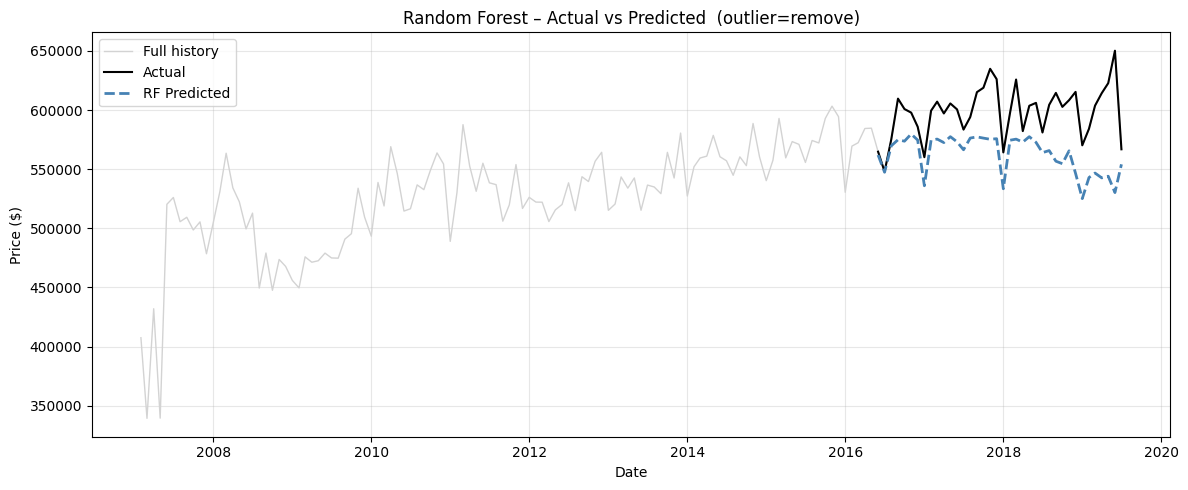

Feature importances:
 sales_count     0.4889
year_scaled     0.3362
avg_bedrooms    0.0805
house_ratio     0.0506
month_sin       0.0247
month_cos       0.0192
dtype: float64


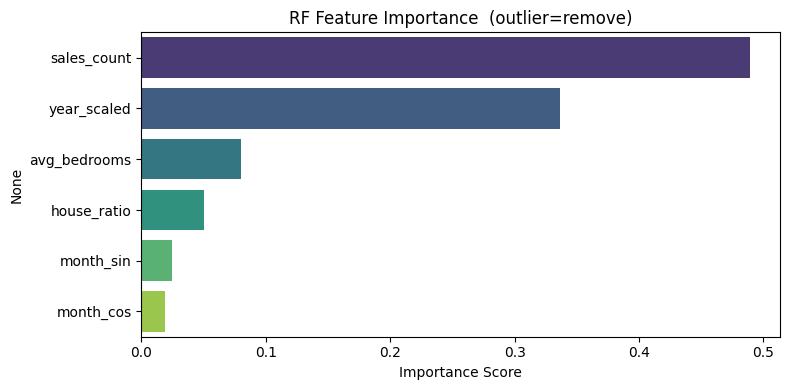

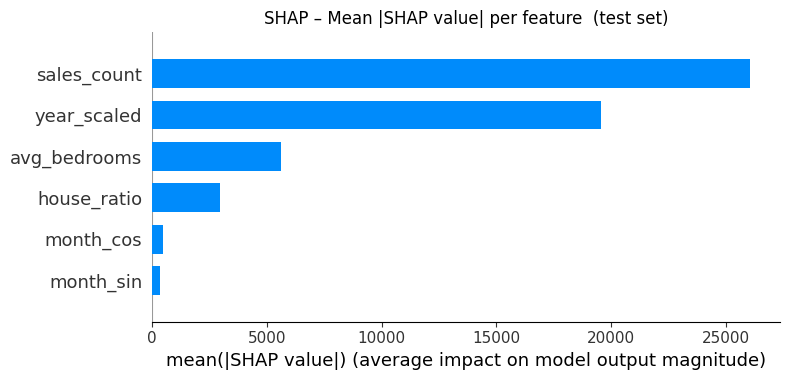

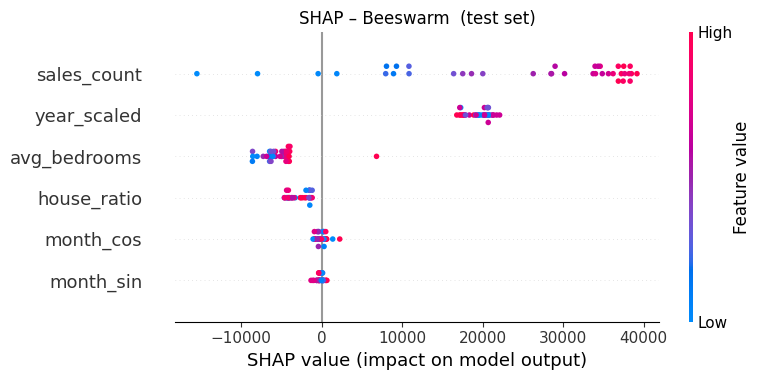

[LSTM] RMSE (with seasonality, remove): $29,604.29


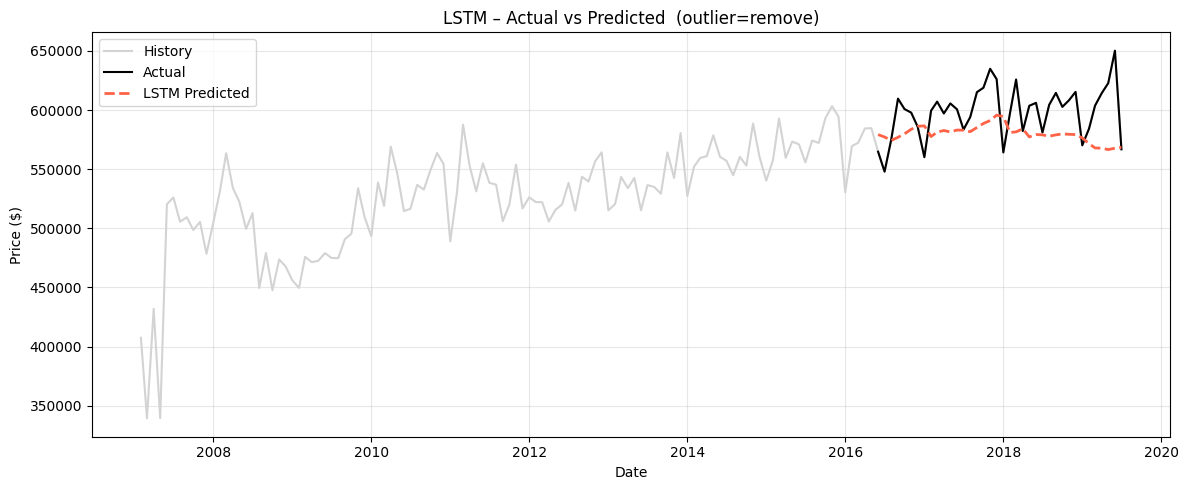

100%|██████████| 38/38 [00:27<00:00,  1.40it/s]


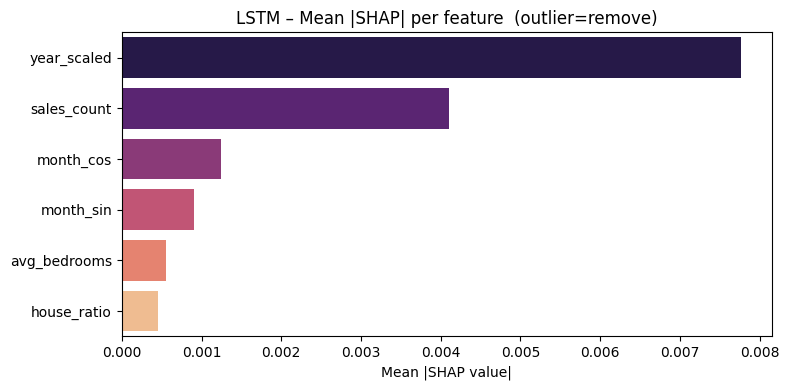

Train: 112 months | Test: 38 months
                                        SARIMAX Results                                        
Dep. Variable:                                   price   No. Observations:                  112
Model:             SARIMAX(0, 1, 1)x(1, 0, [1, 2], 12)   Log Likelihood               -1265.494
Date:                                 Fri, 20 Feb 2026   AIC                           2546.988
Time:                                         14:35:39   BIC                           2568.665
Sample:                                     02-01-2007   HQIC                          2555.782
                                          - 05-01-2016                                         
Covariance Type:                                robust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
avg_bedrooms  1.499e+05   2.91e+04

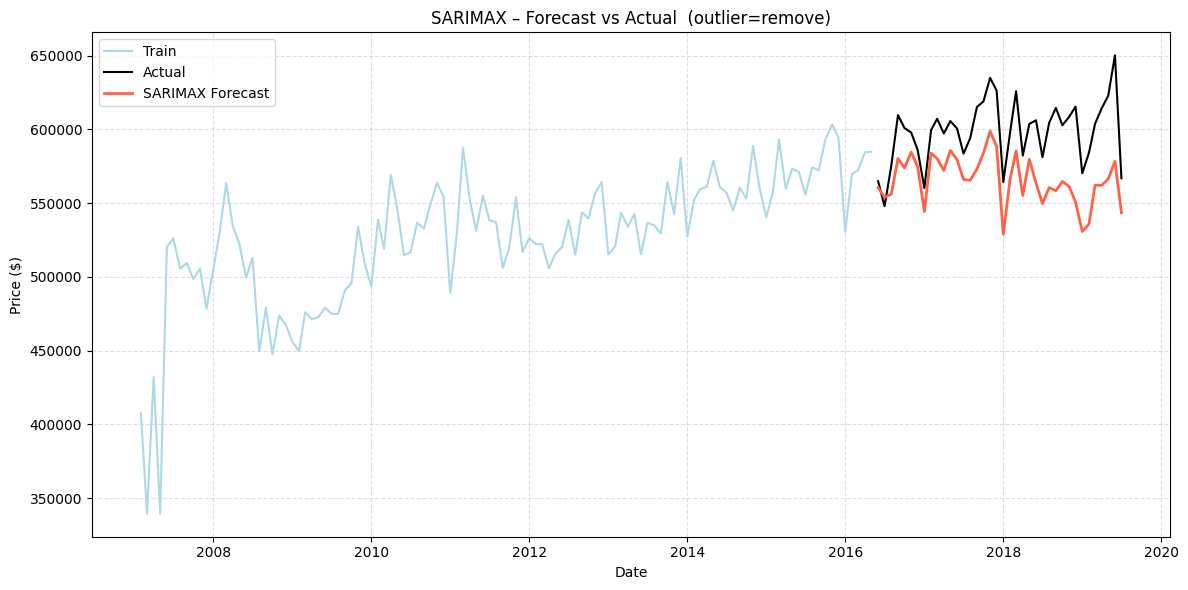

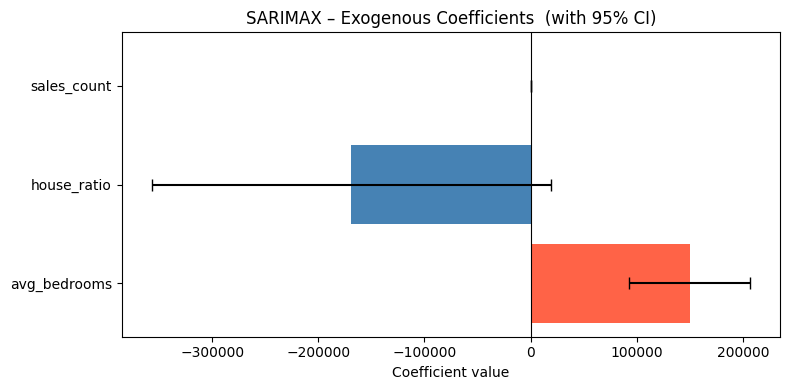


=== Model Comparison (with seasonality features) ===
              Model       RMSE $
LSTM (multivariate) 29604.288687
            SARIMAX 36297.906605
      Random Forest 42772.018364


,Model,RMSE $
1,LSTM (multivariate),29604.288687
2,SARIMAX,36297.906605
0,Random Forest,42772.018364


In [59]:
# =============================================================================
# 4.  COMPARISON TABLE
# =============================================================================


def compare_all_models(monthly_df_cleaned, train_size, type_of_outlier="remove"):
    """Run all three models and print a side-by-side RMSE table."""
    _, rmse_rf, _ = run_random_forest_with_seasonality(
        monthly_df_cleaned, train_size, type_of_outlier
    )
    _, rmse_lstm, _ = run_lstm_with_seasonality(
        monthly_df_cleaned, train_size, type_of_outlier
    )
    fit_sarimax, rmse_sarimax = run_sarimax_with_seasonality(
        monthly_df_cleaned, train_size, type_of_outlier
    )

    results = pd.DataFrame(
        {
            "Model": ["Random Forest", "LSTM (multivariate)", "SARIMAX"],
            "RMSE $": [rmse_rf, rmse_lstm, rmse_sarimax],
        }
    ).sort_values("RMSE $")

    print("\n=== Model Comparison (with seasonality features) ===")
    print(results.to_string(index=False))
    return results

# Run the comparison for the 'remove' outlier strategy (best RMSE in earlier runs)
_, monthly, monthly_df_cleaned = pipeline(df, type_of_outlier='remove', plotting=False)
compare_all_models(monthly_df_cleaned, train_size, type_of_outlier='remove')